# Analyse-Notebook

Dieses Notebook liest die aggregierten Artefakte aus `docs/analysis` ein und
baut daraus einen reproduzierbaren Ueberblick ueber Volumen, Zeitverlauf,
Bezirksmuster und Kategorieverschiebungen.

Hinweise:
- Die Pfade werden relativ zum Projekt automatisch gefunden.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

BUCKET_ORDER = ["00-04", "04-08", "08-12", "12-16", "16-20", "20-24"]


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "models").exists():
            return candidate
    raise FileNotFoundError("Projektwurzel mit src/ und models/ wurde nicht gefunden.")


def locate_analysis_dir(base_dir: Path) -> Path:
    candidates = [
        base_dir / "docs" / "analysis",
        base_dir / "analysis",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Kein Analyseordner gefunden.")


BASE_DIR = find_repo_root(Path.cwd())
ANALYSIS_DIR = locate_analysis_dir(BASE_DIR)

print(f"BASE_DIR    : {BASE_DIR}")
print(f"ANALYSIS_DIR: {ANALYSIS_DIR}")


BASE_DIR    : C:\Users\reneb\Desktop\crime prediction
ANALYSIS_DIR: C:\Users\reneb\Desktop\crime prediction\docs\analysis


In [2]:
TABLE_FILES = {
    "year": "all_categories_by_year.csv",
    "month": "all_categories_by_month.csv",
    "place": "all_categories_by_place.csv",
    "place_year": "all_categories_by_place_year.csv",
    "bucket": "all_categories_by_time_bucket_exact.csv",
    "category_trends": "category_trend_summary.csv",
    "place_trends": "overall_place_trend_summary.csv",
    "place_shift": "category_place_shift_summary.csv",
    "bucket_shift": "category_time_bucket_shift_summary.csv",
    "edge_cases": "edge_cases_summary.csv",
}

tables = {
    name: pd.read_csv(ANALYSIS_DIR / filename, encoding="utf-8-sig")
    for name, filename in TABLE_FILES.items()
}

shape_df = pd.DataFrame(
    [
        {"table": name, "rows": frame.shape[0], "cols": frame.shape[1]}
        for name, frame in tables.items()
    ]
).sort_values("table")

display(shape_df)


,table,rows,cols
4,bucket,309,6
8,bucket_shift,60,11
5,category_trends,62,10
9,edge_cases,844,13
1,month,1515,5
2,place,678,5
7,place_shift,61,11
6,place_trends,29,9
3,place_year,1693,8
0,year,225,5


In [3]:
year_totals = (
    tables["year"]
    .groupby("year", as_index=False)["count"]
    .sum()
    .sort_values("year")
)

month_totals = (
    tables["month"]
    .groupby("month", as_index=False)["count"]
    .sum()
    .sort_values("month")
)
month_totals["month"] = pd.to_datetime(month_totals["month"] + "-01")

place_trends = tables["place_trends"].copy()
place_trends["is_non_standard_place"] = (
    place_trends["is_non_standard_place"].fillna(False).astype(bool)
)
standard_places = place_trends.loc[~place_trends["is_non_standard_place"]].copy()
standard_places["delta_23_25_count"] = (
    standard_places["count_2025"] - standard_places["count_2023"]
)

bucket_totals = (
    tables["bucket"]
    .groupby("time_bucket", as_index=False)["count"]
    .sum()
)
bucket_totals["time_bucket"] = pd.Categorical(
    bucket_totals["time_bucket"],
    categories=BUCKET_ORDER,
    ordered=True,
)
bucket_totals = bucket_totals.sort_values("time_bucket")

summary = pd.DataFrame(
    [
        {"metric": "events_total", "value": int(year_totals["count"].sum())},
        {"metric": "years_covered", "value": int(year_totals["year"].nunique())},
        {"metric": "categories", "value": int(tables["year"]["category"].nunique())},
        {"metric": "places", "value": int(tables["place"]["place"].nunique())},
        {"metric": "standard_places", "value": int(standard_places["place"].nunique())},
        {"metric": "exact_time_categories", "value": int(tables["bucket"]["category"].nunique())},
    ]
)

display(summary)
display(year_totals)


,metric,value
0,events_total,7015
1,years_covered,5
2,categories,62
3,places,29
4,standard_places,13
5,exact_time_categories,60


,year,count
0,2022,2
1,2023,2190
2,2024,2393
3,2025,2048
4,2026,382


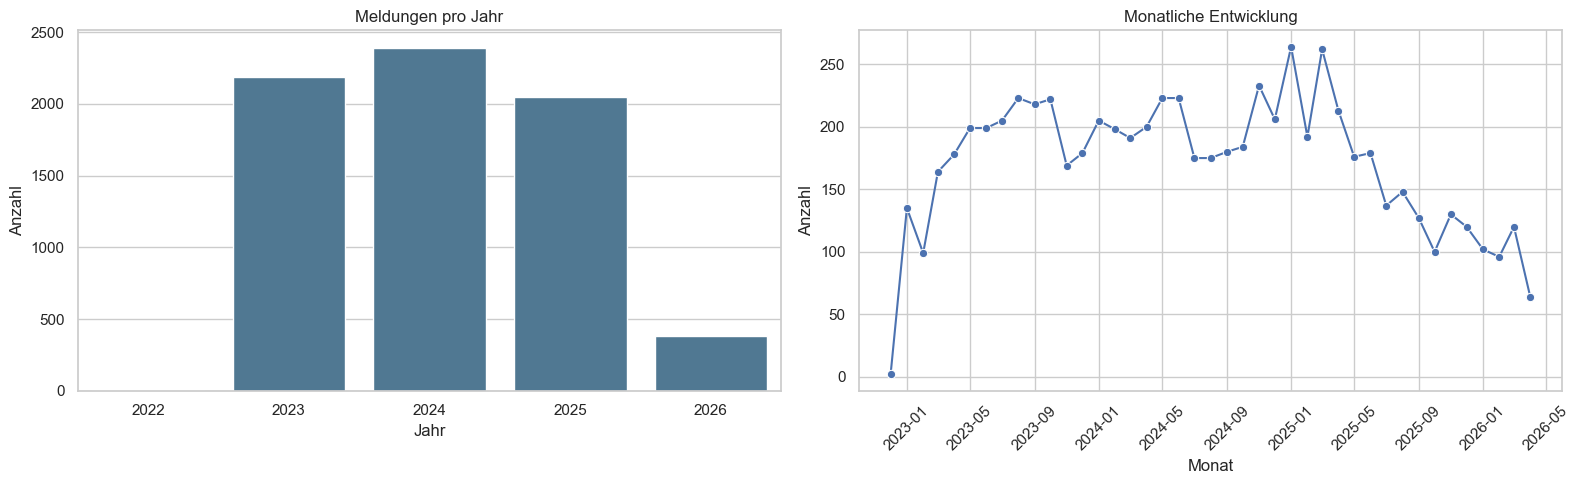

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(ax=axes[0], data=year_totals, x="year", y="count", color="#457b9d")
axes[0].set_title("Meldungen pro Jahr")
axes[0].set_xlabel("Jahr")
axes[0].set_ylabel("Anzahl")

sns.lineplot(ax=axes[1], data=month_totals, x="month", y="count", marker="o")
axes[1].set_title("Monatliche Entwicklung")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Anzahl")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


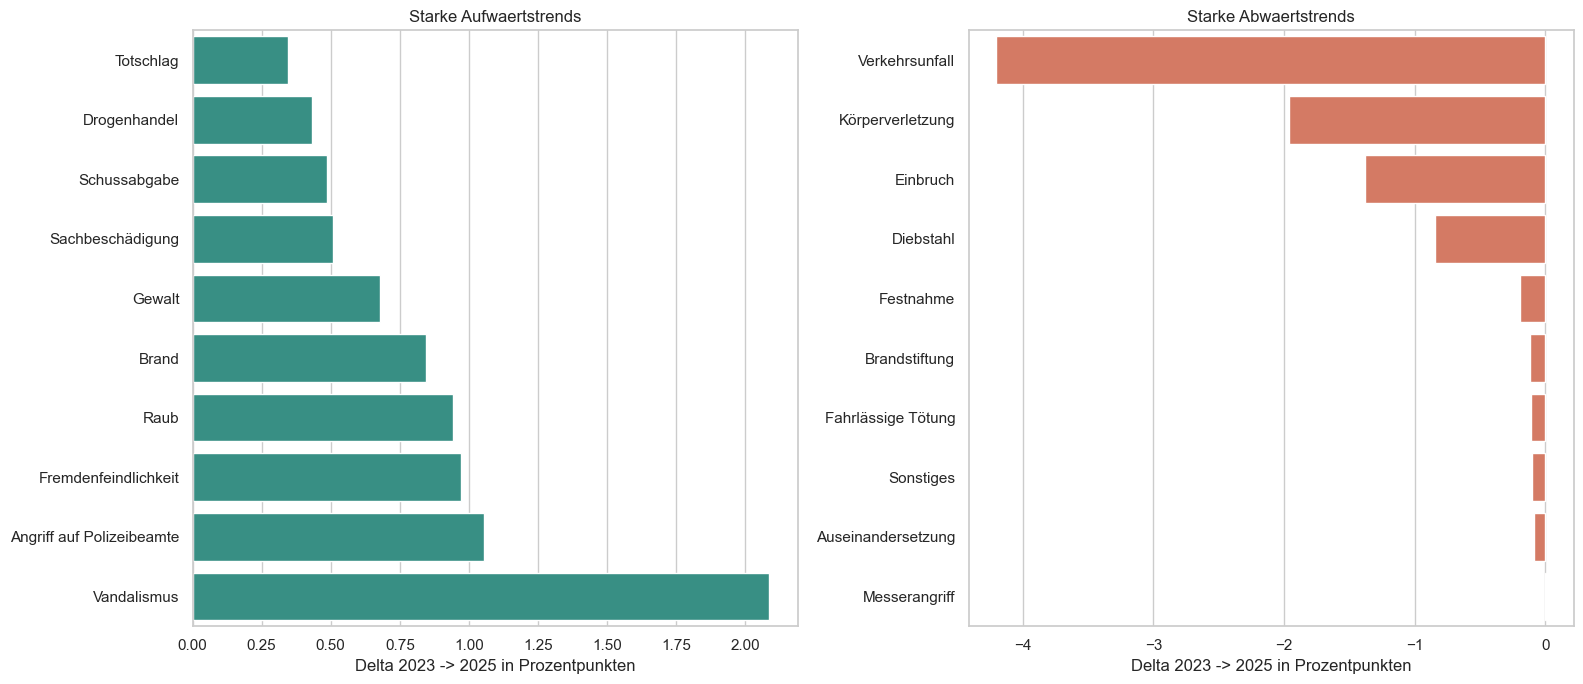

,category,count_2023,count_2024,count_2025,share_2023,share_2024,share_2025,delta_23_25_pp,core_total_count,trend_reliability
0,Vandalismus,73,116,111,0.033333,0.048475,0.054199,2.086589,300,high
1,Angriff auf Polizeibeamte,55,80,73,0.025114,0.033431,0.035645,1.053038,208,high
2,Fremdenfeindlichkeit,45,55,62,0.020548,0.022984,0.030273,0.972549,162,medium
3,Raub,144,159,154,0.065753,0.066444,0.075195,0.944189,457,high
4,Brand,66,97,79,0.030137,0.040535,0.038574,0.843723,242,high
5,Gewalt,75,77,84,0.034247,0.032177,0.041016,0.676905,236,high
7,Sachbeschädigung,37,46,45,0.016895,0.019223,0.021973,0.507768,128,medium
8,Schussabgabe,30,27,38,0.013699,0.011283,0.018555,0.485606,95,medium
10,Drogenhandel,29,34,36,0.013242,0.014208,0.017578,0.433612,99,medium
11,Totschlag,32,39,37,0.014612,0.016298,0.018066,0.345453,108,medium


In [5]:
category_trends = tables["category_trends"].copy()
reliable_trends = category_trends.loc[
    category_trends["trend_reliability"].isin(["high", "medium"])
].copy()

rising = reliable_trends.nlargest(10, "delta_23_25_pp").sort_values("delta_23_25_pp")
falling = reliable_trends.nsmallest(10, "delta_23_25_pp").sort_values("delta_23_25_pp")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(ax=axes[0], data=rising, x="delta_23_25_pp", y="category", color="#2a9d8f")
axes[0].set_title("Starke Aufwaertstrends")
axes[0].set_xlabel("Delta 2023 -> 2025 in Prozentpunkten")
axes[0].set_ylabel("")

sns.barplot(ax=axes[1], data=falling, x="delta_23_25_pp", y="category", color="#e76f51")
axes[1].set_title("Starke Abwaertstrends")
axes[1].set_xlabel("Delta 2023 -> 2025 in Prozentpunkten")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(
    reliable_trends.sort_values("delta_23_25_pp", ascending=False).head(15)
)


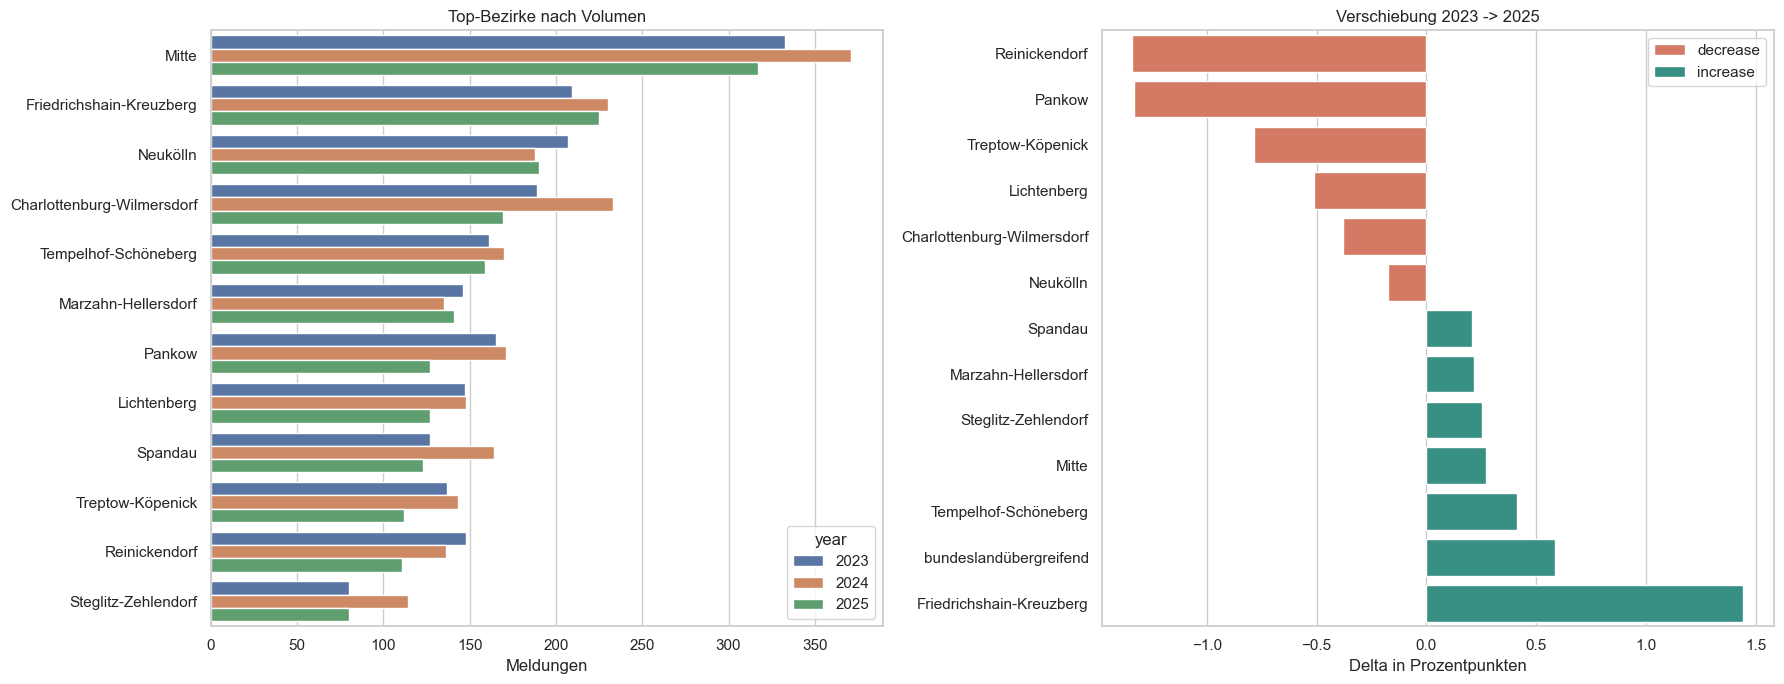

,place,count_2023,count_2024,count_2025,share_2023,share_2024,share_2025,delta_23_25_pp,is_non_standard_place,delta_23_25_count
10,Mitte,333,371,317,0.152055,0.155036,0.154785,0.273036,False,-16
1,Friedrichshain-Kreuzberg,209,230,225,0.095434,0.096114,0.109863,1.442949,False,16
14,Neukölln,207,188,190,0.094521,0.078562,0.092773,-0.174711,False,-17
9,Charlottenburg-Wilmersdorf,189,233,169,0.086301,0.097367,0.082520,-0.378184,False,-20
8,Tempelhof-Schöneberg,161,170,159,0.073516,0.071041,0.077637,0.412074,False,-2
12,Marzahn-Hellersdorf,146,135,141,0.066667,0.056415,0.068848,0.218099,False,-5
7,Lichtenberg,147,148,127,0.067123,0.061847,0.062012,-0.511157,False,-20
3,Pankow,165,171,127,0.075342,0.071458,0.062012,-1.333075,False,-38
13,Spandau,127,164,123,0.057991,0.068533,0.060059,0.206773,False,-4
4,Treptow-Köpenick,137,143,112,0.062557,0.059758,0.054688,-0.786958,False,-25


In [6]:
top_places = standard_places.nlargest(12, "count_2025").copy()
top_places_long = top_places.melt(
    id_vars="place",
    value_vars=["count_2023", "count_2024", "count_2025"],
    var_name="year",
    value_name="count",
)
top_places_long["year"] = top_places_long["year"].str.replace("count_", "", regex=False)

delta_places = standard_places.sort_values("delta_23_25_pp").copy()
delta_places["direction"] = delta_places["delta_23_25_pp"].ge(0).map(
    {True: "increase", False: "decrease"}
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    ax=axes[0],
    data=top_places_long,
    x="count",
    y="place",
    hue="year",
)
axes[0].set_title("Top-Bezirke nach Volumen")
axes[0].set_xlabel("Meldungen")
axes[0].set_ylabel("")

sns.barplot(
    ax=axes[1],
    data=delta_places,
    x="delta_23_25_pp",
    y="place",
    hue="direction",
    dodge=False,
    palette={"increase": "#2a9d8f", "decrease": "#e76f51"},
)
axes[1].set_title("Verschiebung 2023 -> 2025")
axes[1].set_xlabel("Delta in Prozentpunkten")
axes[1].set_ylabel("")
axes[1].legend(title="")

plt.tight_layout()
plt.show()

display(standard_places.sort_values("count_2025", ascending=False))


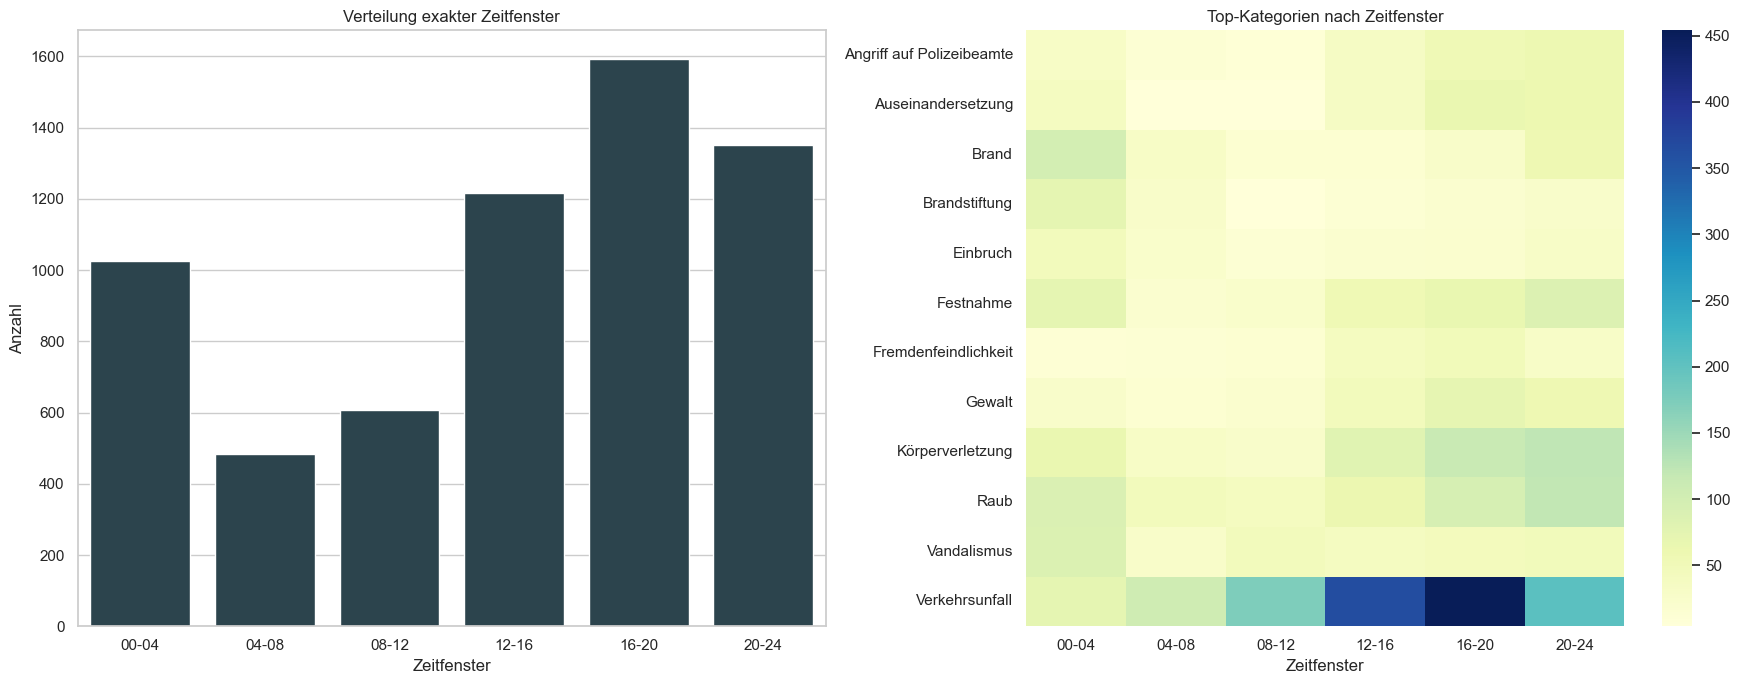

,time_bucket,count
0,00-04,1026
1,04-08,483
2,08-12,606
3,12-16,1216
4,16-20,1593
5,20-24,1351


In [7]:
bucket_counts = (
    tables["bucket"]
    .groupby(["time_bucket", "category"], as_index=False)["count"]
    .sum()
)

top_exact_categories = (
    bucket_counts.groupby("category")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

bucket_heatmap = (
    bucket_counts.loc[bucket_counts["category"].isin(top_exact_categories)]
    .pivot(index="category", columns="time_bucket", values="count")
    .reindex(columns=BUCKET_ORDER)
    .fillna(0)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(ax=axes[0], data=bucket_totals, x="time_bucket", y="count", color="#264653")
axes[0].set_title("Verteilung exakter Zeitfenster")
axes[0].set_xlabel("Zeitfenster")
axes[0].set_ylabel("Anzahl")

sns.heatmap(bucket_heatmap, ax=axes[1], cmap="YlGnBu")
axes[1].set_title("Top-Kategorien nach Zeitfenster")
axes[1].set_xlabel("Zeitfenster")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(bucket_totals)


In [8]:
place_shift = tables["place_shift"].copy()
bucket_shift = tables["bucket_shift"].copy()

place_shift = place_shift.loc[
    place_shift["trend_reliability"].isin(["high", "medium"])
].sort_values("delta_23_25_pp", ascending=False)

bucket_shift = bucket_shift.loc[
    bucket_shift["trend_reliability"].isin(["high", "medium"])
].sort_values("delta_23_25_pp", ascending=False)

print("Top place shifts")
display(place_shift.head(10))

print("Top bucket shifts")
display(bucket_shift.head(10))


Top place shifts


,category,count_2023,count_2024,count_2025,core_total_count,trend_reliability,strongest_place_shift,share_2023,share_2024,share_2025,delta_23_25_pp
33,Vermisste Person,38,33,37,108,medium,Pankow,0.052632,0.060606,0.243243,19.061166
34,Schussabgabe,30,27,37,94,medium,Tempelhof-Schöneberg,0.000000,0.037037,0.189189,18.918919
43,Fahrerflucht,41,47,44,132,medium,Charlottenburg-Wilmersdorf,0.073171,0.191489,0.204545,13.137472
47,Fremdenfeindlichkeit,44,54,62,160,medium,Mitte,0.113636,0.129630,0.225806,11.217009
49,Fahrlässige Tötung,28,33,23,84,medium,Pankow,0.071429,0.121212,0.173913,10.248447
50,Auseinandersetzung,65,83,57,205,high,Mitte,0.092308,0.301205,0.192982,10.067476
53,Sachbeschädigung,36,45,43,124,medium,Neukölln,0.083333,0.044444,0.162791,7.945736
55,Brand,64,92,75,231,high,Lichtenberg,0.046875,0.130435,0.120000,7.312500
56,Einbruch,72,46,37,155,medium,Tempelhof-Schöneberg,0.069444,0.108696,0.135135,6.569069
57,Festnahme,104,117,86,307,high,Spandau,0.028846,0.051282,0.093023,6.417710


Top bucket shifts


,category,exact_count_2023,exact_count_2024,exact_count_2025,core_exact_count,trend_reliability,strongest_bucket_shift,share_2023,share_2024,share_2025,delta_23_25_pp
29,Totschlag,28,33,35,96,medium,08-12,0.107143,0.121212,0.342857,23.571429
35,Schussabgabe,29,26,36,91,medium,00-04,0.172414,0.230769,0.361111,18.869732
38,Brand,62,93,76,231,high,00-04,0.306452,0.430108,0.486842,18.039049
44,Sachbeschädigung,34,42,43,119,medium,12-16,0.117647,0.166667,0.255814,13.816689
54,Brandstiftung,50,55,48,153,medium,12-16,0.040000,0.072727,0.104167,6.416667
55,Auseinandersetzung,62,82,55,199,medium,00-04,0.145161,0.195122,0.200000,5.483871
56,Gewalt,67,75,78,220,high,00-04,0.089552,0.120000,0.141026,5.147340
57,Verkehrsunfall,475,475,358,1308,high,20-24,0.164211,0.155789,0.125698,-3.851220
53,Raub,135,149,149,433,high,04-08,0.125926,0.114094,0.060403,-6.552324
52,Fahrerflucht,41,47,44,132,medium,12-16,0.219512,0.127660,0.136364,-8.314856
